# Adaptive POD For Reducing Error Certificates

Previously, in Tutorial [2](./2_POD_solve_example.ipynb), we saw that we can compute an approximation of the full order solution using a smaller number of logarithmically spaced snapshots. In addition, we saw that we could compute upper bound error certificates at negligible computational cost corresponding to the difference between the ROM and full order solutions:


$|(\mathcal{R}[\alpha B, \omega])_{ij} - (\mathcal{R}^{\rm POD}[\alpha B, \omega])_{ij}| \le (\Delta[\omega])_{ij}$

$|(\mathcal{I}[\alpha B, \omega])_{ij} - (\mathcal{I}^{\rm POD}[\alpha B, \omega])_{ij}| \le (\Delta[\omega])_{ij}$


In this tutorial we demonstrate how we can use these error certificates to intelligently select additional snapshot frequencies that when included in the POD efficiently reduce the error certificates. This provides improved confidence in the POD output and consiquently improved confidence in the POD tensor coefficients returned by the POD method at reduced computational work when compared to logarithmically spaced snapshots.

## Workflow
The adaptive POD mode of MPT calculator operates as follows:

<img src="Figures/adaptive_POD_flowchart.png" alt="Adaptive POD Flowchart"/>


Frequencies are flagged for refinement based on a peak finding algorithm that determines the position between two snapshots where the error is greatest. This lets us add additional snapshots corresponding to other peaks in $(\Delta[\omega])_{ij}$ if necessary. Alternatively, if the largest $(\Delta[\omega])_{ij}$  corresponds to the largest frequency (not a peak), then the mean frequency of the largest 2 snapshots is used. 

n.b. We do not need to recalculate the full order solutions for all $n$ frequencies each iteration, only the small number of additional snapshots. 

## Choosing Tolerance
To account for different sized objects, which give rise to a larger magnitude $(\mathcal{R}[\alpha B, \omega])_{ij}$, $(\mathcal{I}[\alpha B, \omega])_{ij}$ and larger $(\Delta[\omega])_{ij}$ we scale the tolerance by the object volume $V$.

To set the tolerance, we change
```python
# (float) Stopping tolerance (max(error)/object_volume) for the iterative process.
Tol = 0.001
```
We do this within the $\texttt{IterativePODParameters()}$ function in $\texttt{Settings/Settings.py}$ 

Similarly, we can set the maximum number of iterations using $\texttt{MaxIter}$:
```python
# (int) Maximum number of iterations that will run in the iterative process.
MaxIter = 4
```

## Choosing Number of Additional Snapshots Per Iteration
Typically in iterative refinement schemes such as these, more that one frequency is flagged for refinement. In MPT-Calculator, this is controlled by $\texttt{NAdditionalSnapshotsPerIter}$ in $\texttt{Settings.py}$:
```python
# (int) Number of additional snapshots to add per iteration.
NAdditionalSnapshotsPerIter = 2
```

## Plotting Results for Each Iteration
Output tensor coefficients, including error certificates can be plotted using the 
```python
# (int) Number of additional snapshots to add per iteration.
 PlotUpdatedPOD = True
```
argument in in $\texttt{Settings.py}$.

In addition to generating and displaying the figures, the figures are saved as pdfs in the Graphs subdirectory.

## Usage
To use the iterative POD method, we set $\texttt{use\_iterative\_POD = True}$ when calling $\texttt{main}$. Note that $\texttt{PODErrorBars}$ must be set to $\texttt{True}$ in $\texttt{Settings.py}$.

In this example, we use the default settings for MPT-Calculator which, recalling from Tutorial [2](./2_POD_solve_example.ipynb), produces large error bars at high frequencies.

In [1]:
import os
# Please edit this line to provide the to the root directory of your copy of MPT-Calculator
Your_Path= r"/home/pdl11/Coding/MPT_calculator/Sept2025/MPT-Calculator"#'C:\Users\James\Desktop\Release_Ready_MPT_Calculator\Restructured_MPT_Calculator'

os.chdir(Your_Path)
os.getcwd()

from main import main
import numpy as np

Materials = ('mat1', 'air', 'mat1')
Updated alpha from OCC file. Alpha=0.001
OCC_sphere_prism_32.geo
[0, 1] 2 ['air', 'mat1']
Mesh Contains Prisms? True
N Prisms: 1312, N Tets: 18085
[0, 1] 2 ['air', 'mat1']


/home/pdl11/Coding/MPT_calculator/Sept2025/MPT-Calculator/main.py:280: UserWarning: It looks like the main function was invoked from a jupyter notebook. 
Currently saving a .ipynb file is done by copying the most recent file in the .ipynb_checkpoints folder. 
Unless you saved the file before running the code, this may not be the correct file.
  warn('It looks like the main function was invoked from a jupyter notebook. \nCurrently saving a .ipynb file is done by copying the most recent file in the .ipynb_checkpoints folder. \nUnless you saved the file before running the code, this may not be the correct file.', stacklevel=1)


Running iterative POD
Parallel Mode? : True
 mesh contains 19397 elements
Running Bilinear Forms Check
Mesh curve order set to:  5
K: Iteration 1: bonus_intord = 2
K: Iteration 2: bonus_intord = 4
K: Iteration 3: bonus_intord = 6
K: Iteration 4: bonus_intord = 8
K: Iteration 5: bonus_intord = 10
K Bilinear Form Converged using order 12
C: Iteration 1: bonus_intord = 2
C: Iteration 2: bonus_intord = 4
C: Iteration 3: bonus_intord = 6
C: Iteration 4: bonus_intord = 8
C: Iteration 5: bonus_intord = 10
C Bilinear Form Converged using order 12


Solving Theta0: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 51995.50it/s]


 solved theta0 problems    


...

Solving Theta1 Snapshots: 100%|██████████████████████████████████████████████████████████████████████████████████| 1/1 [01:42<00:00, 102.82s/it]


manually closed pool
 solved theta1 problems     
 Weighted Error Estimate = 6.20844704284649, Iteration 9
 Iteration 10
 SVD complete                
 Number of retained modes = 13
 Number of retained modes = 13
 Built K, Q, E, and Ger model
manually closed pool
 reduced order systems solved
 Computing Errors
The interval between 1.000e+01 and 1.194e+02 rad/s doesn't seem to be decreasing at the snapshots. Skipping for refinement.
The interval between 1.194e+02 and 1.468e+02 rad/s doesn't seem to be decreasing at the snapshots. Skipping for refinement.
The interval between 1.468e+02 and 1.701e+02 rad/s doesn't seem to be decreasing at the snapshots. Skipping for refinement.
The interval between 1.701e+02 and 2.424e+02 rad/s doesn't seem to be decreasing at the snapshots. Skipping for refinement.
The interval between 2.424e+02 and 3.455e+02 rad/s doesn't seem to be decreasing at the snapshots. Skipping for refinement.
The interval between 3.455e+02 and 2.154e+03 rad/s doesn't seem to b

Solving Theta1 Snapshots: 100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:46<00:00, 46.06s/it]


manually closed pool
 solved theta1 problems     
 Weighted Error Estimate = 6.218922530704032, Iteration 10


/home/pdl11/Coding/MPT_calculator/Sept2025/MPT-Calculator/Functions/POD/PODSweepIterative.py:375: UserWarning: Iterative POD did not reach set tolerance within 10 iterations
  warnings.warn(f'Iterative POD did not reach set tolerance within {max_iter} iterations')


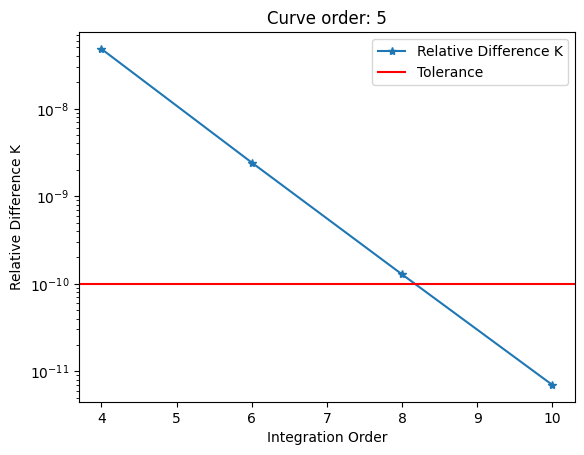

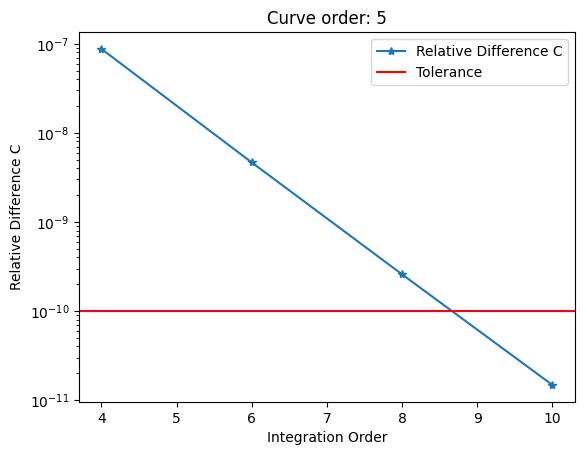

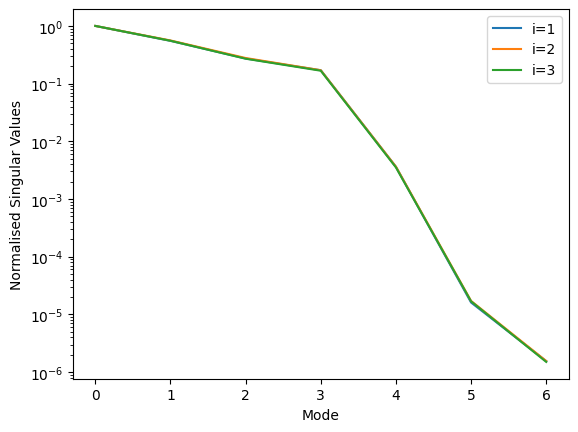

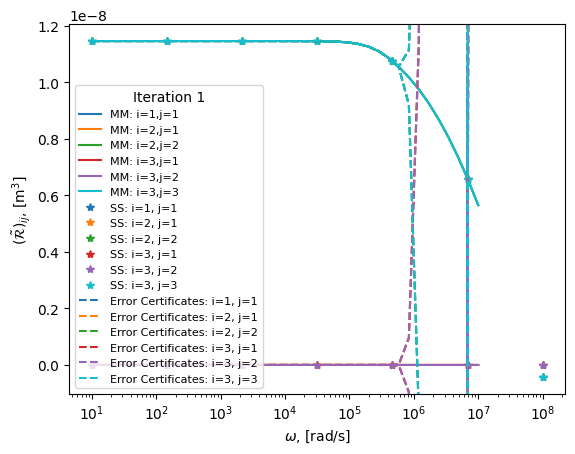

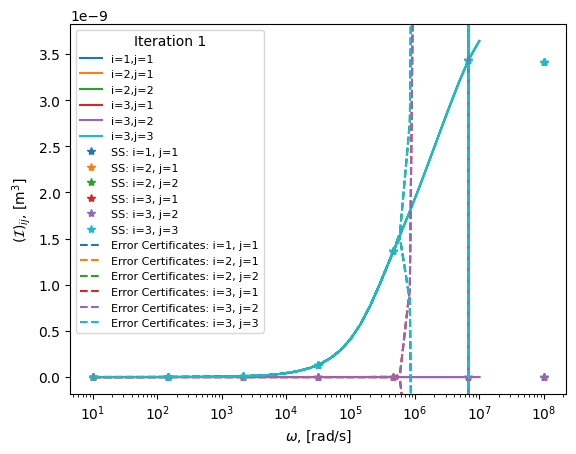

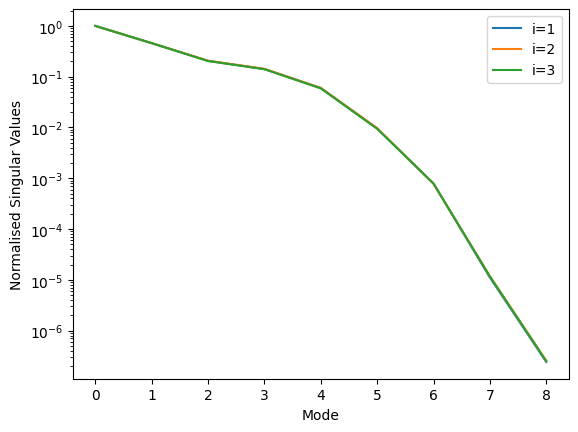

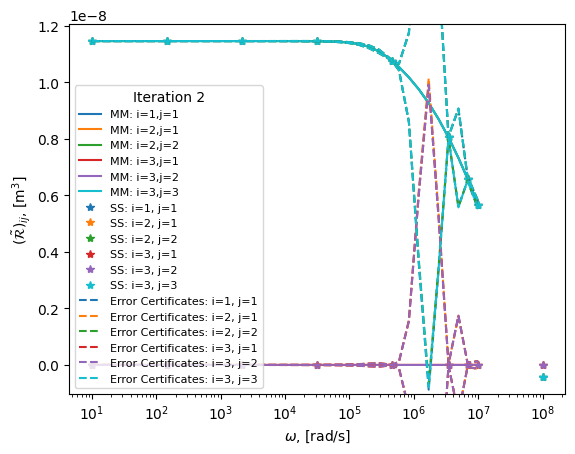

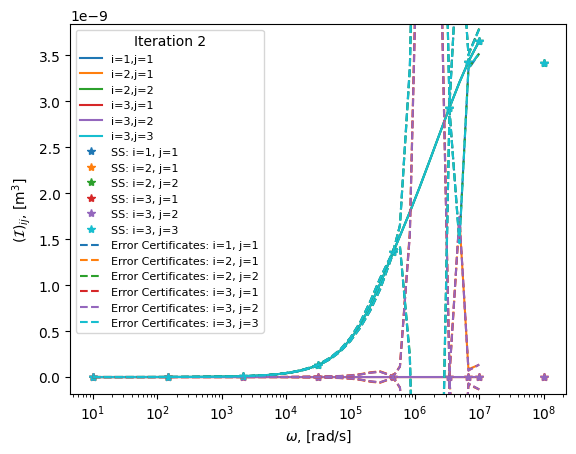

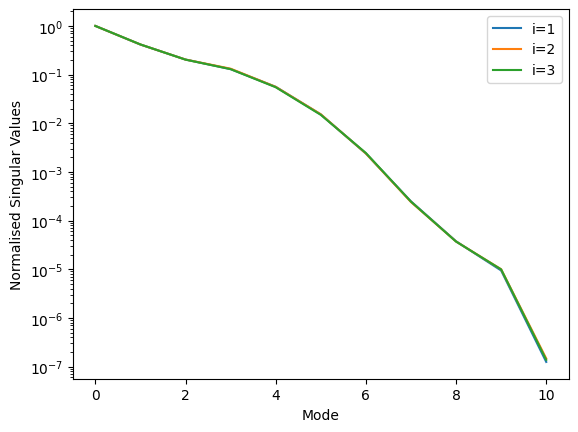

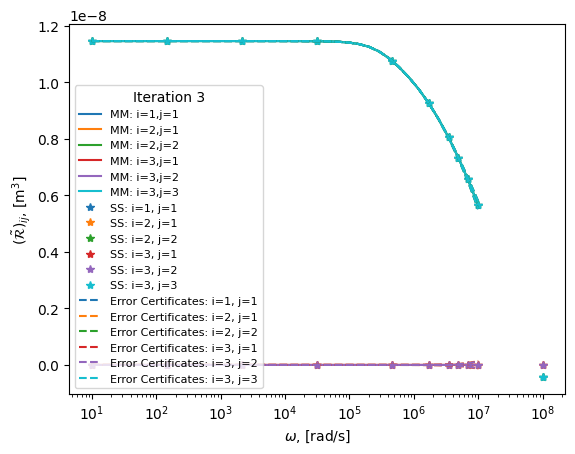

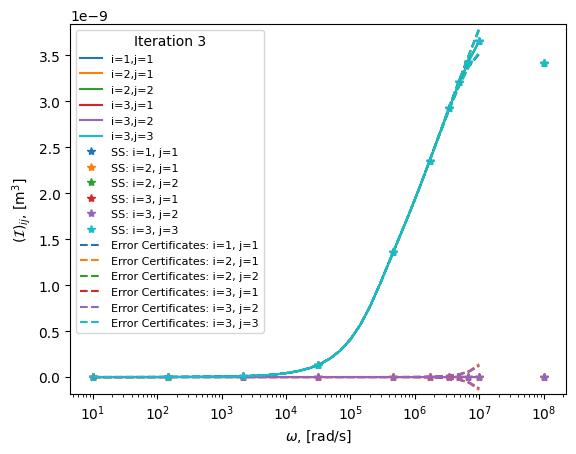

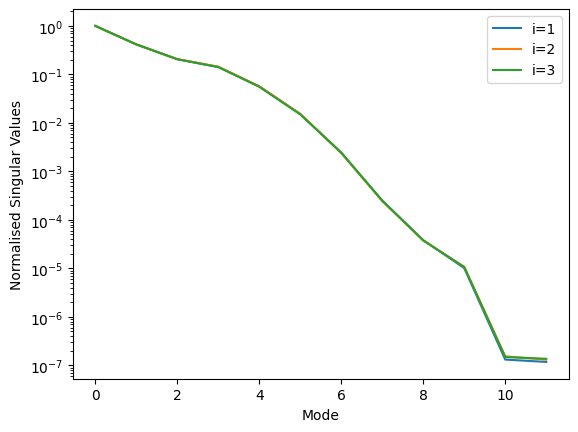

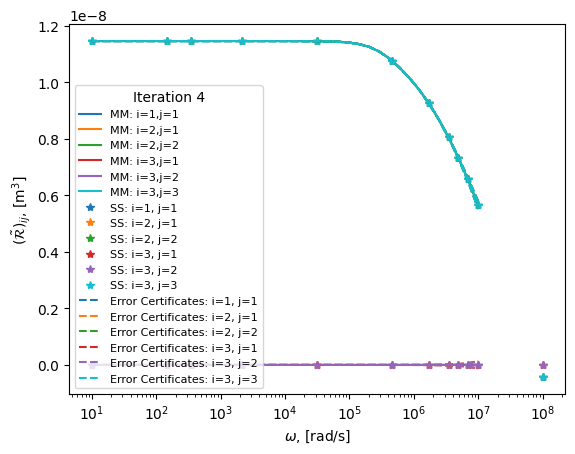

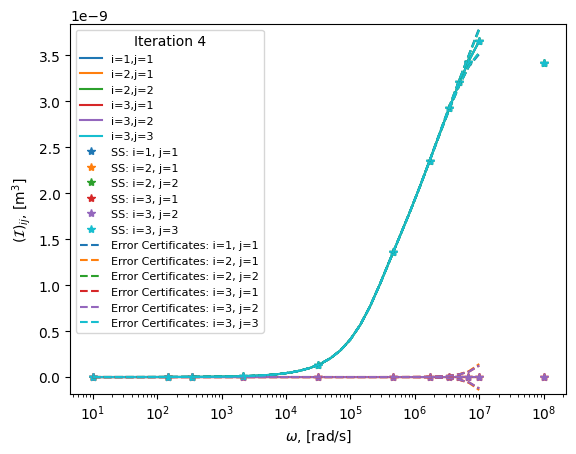

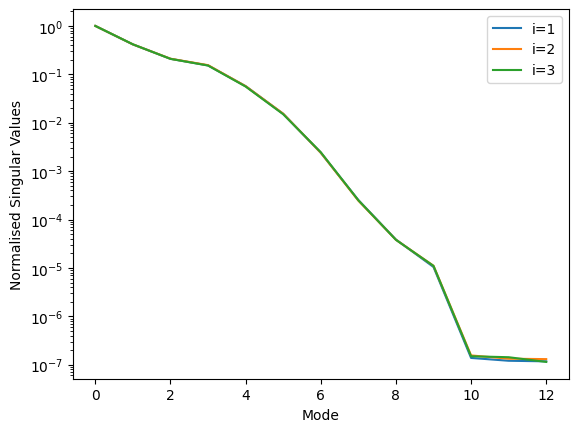

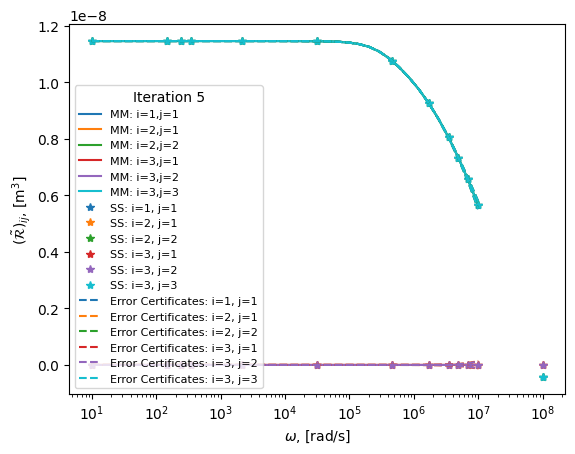

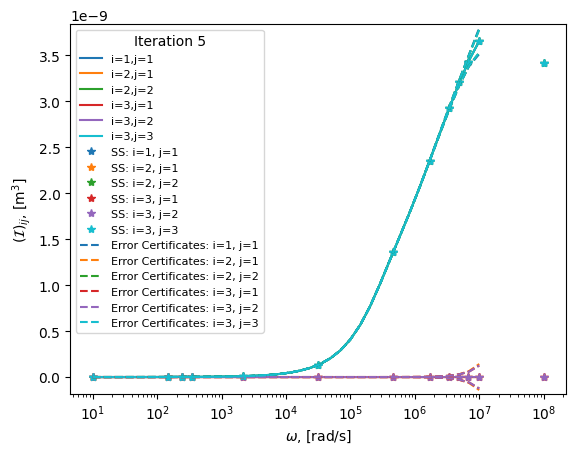

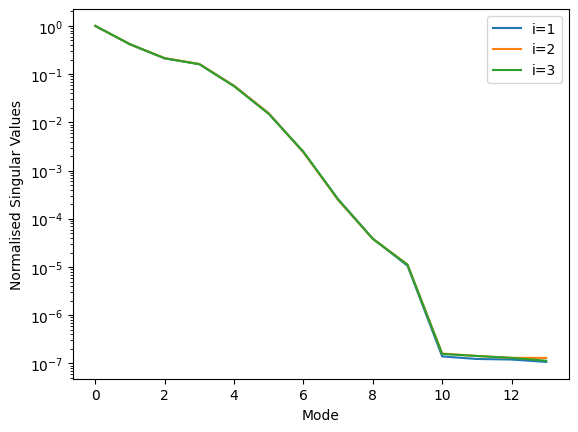

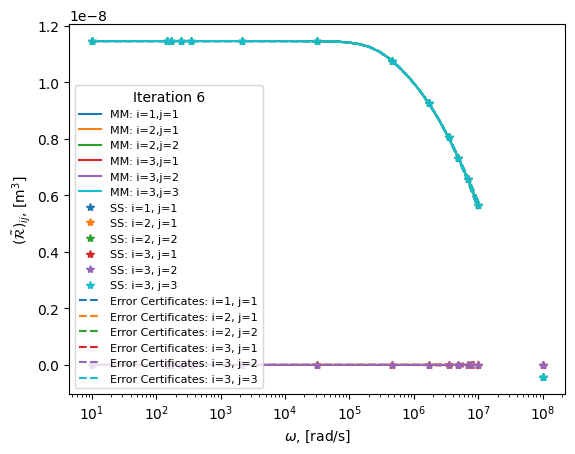

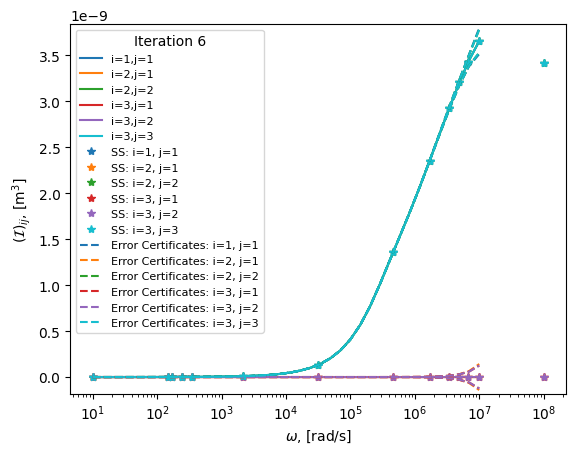

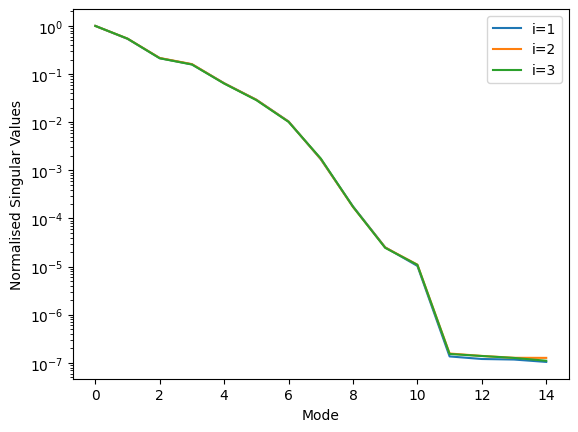

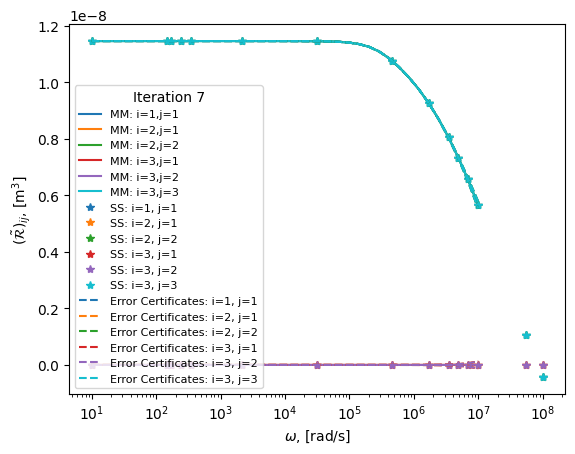

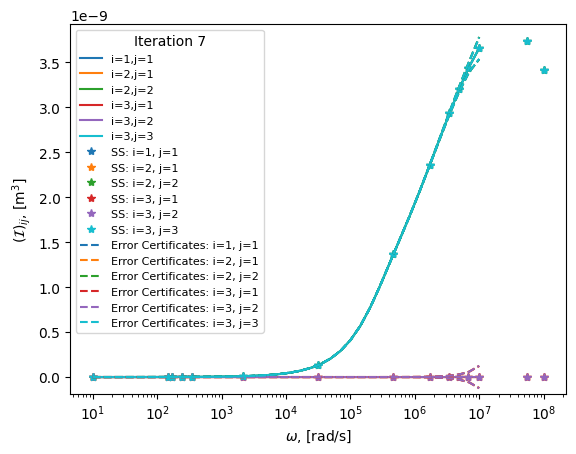

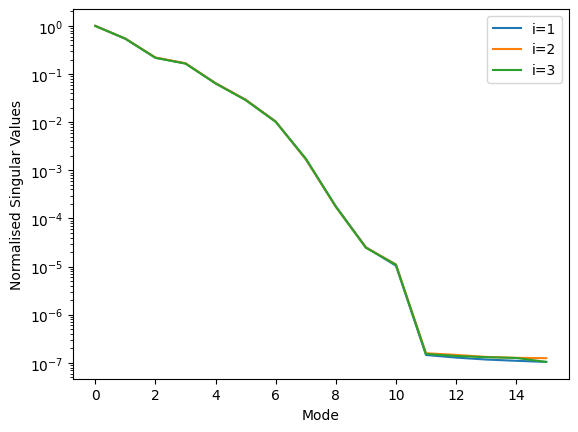

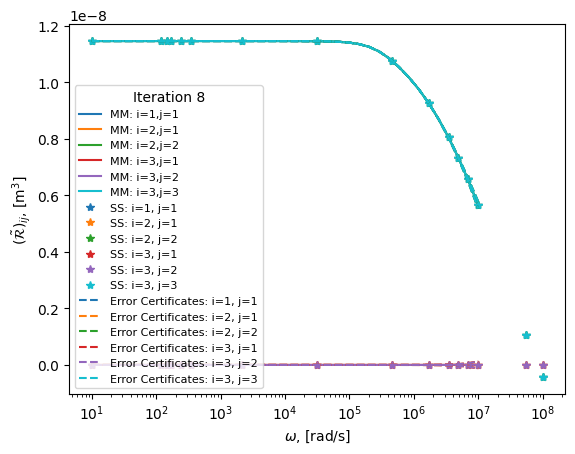

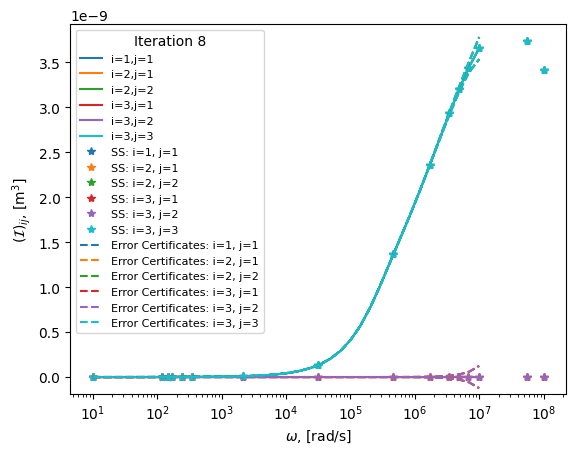

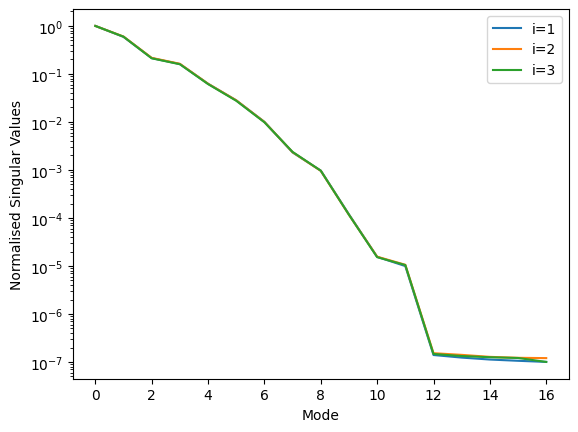

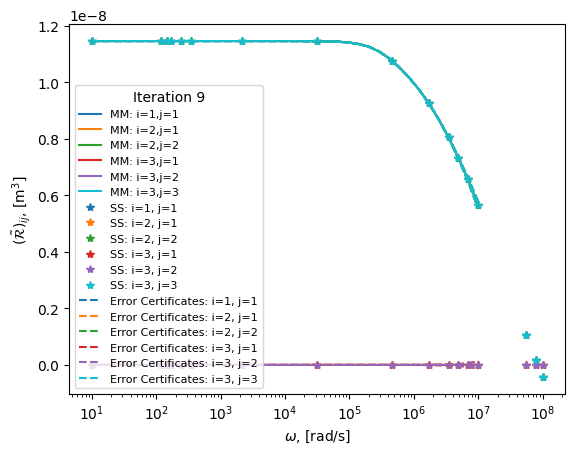

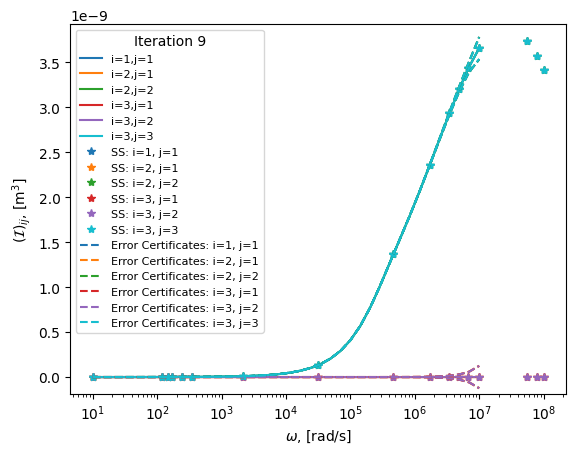

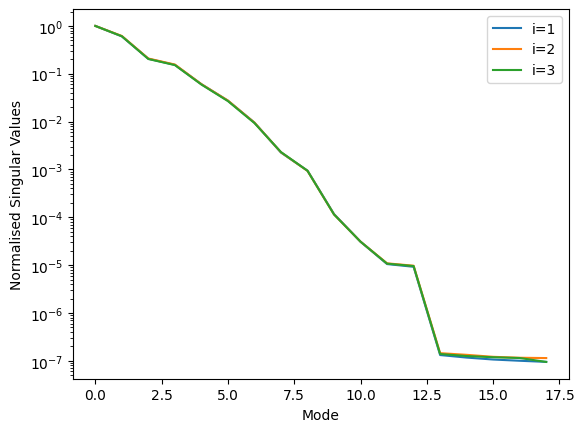

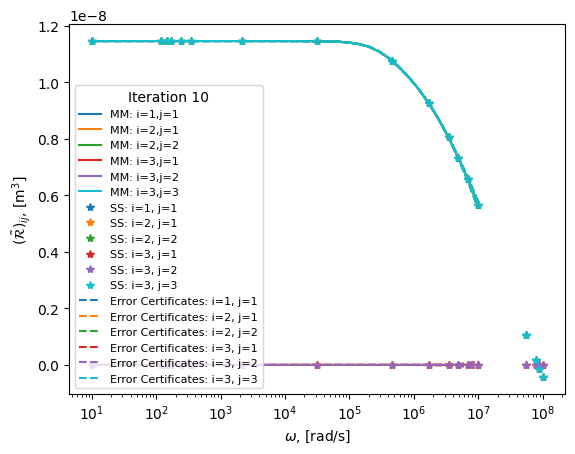

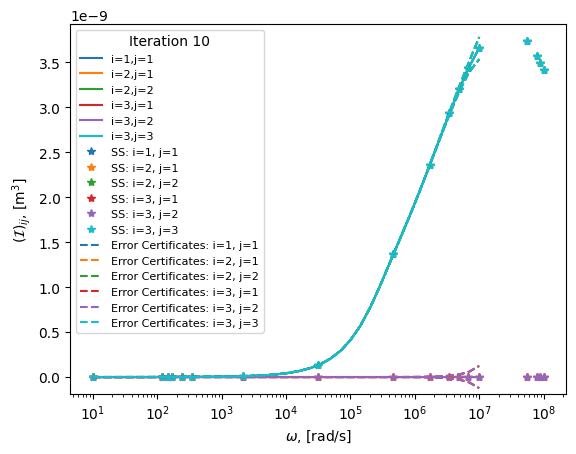

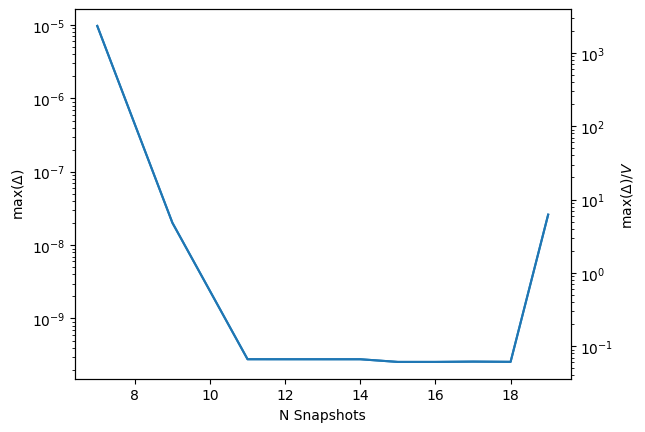

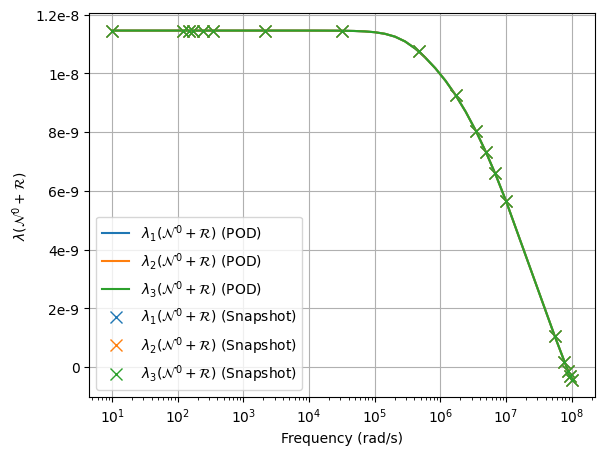

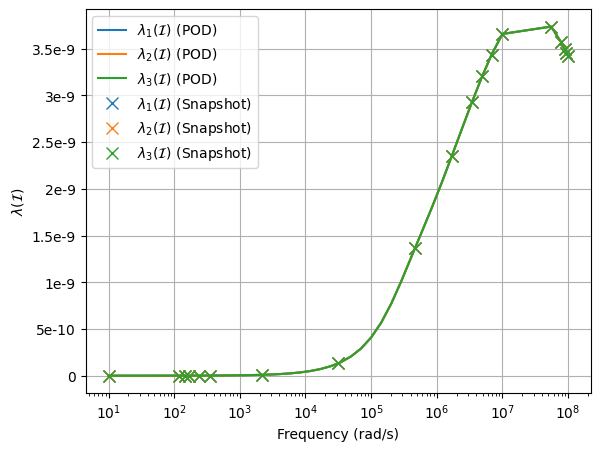

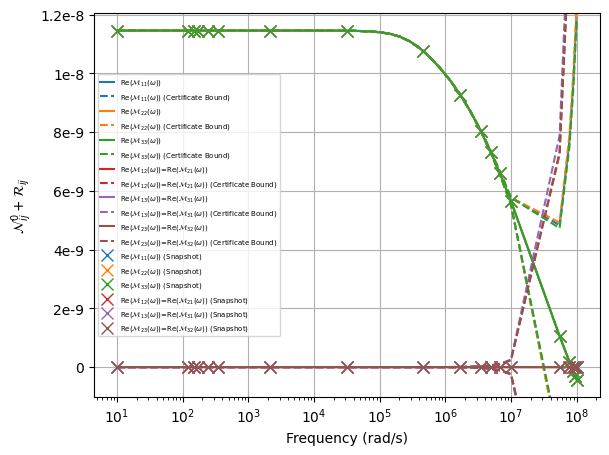

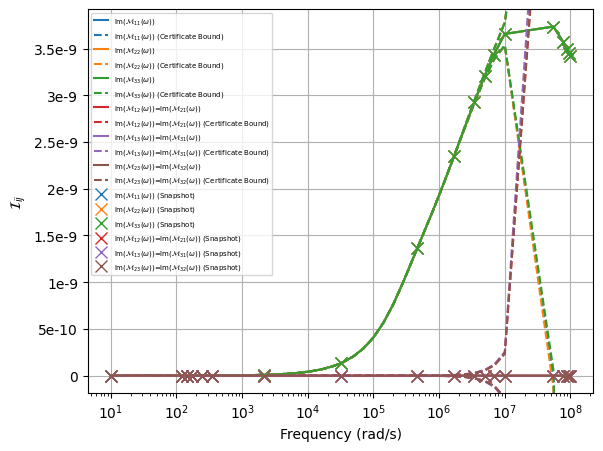

In [2]:
geometry = 'OCC_sphere_prism_32.py'
start = 1
stop = 8
points = 40
order = 3
alpha = 1e-2
N_POD_Points = 7
mesh_coarseness = 'coarse'
frequency_array = np.logspace(1,7,points)

start_stop = (start, stop, points)

result = main(geometry=geometry, alpha=alpha, order=order, h=mesh_coarseness, start_stop=start_stop, frequency_array=frequency_array,
              use_OCC=True,use_POD=True, use_iterative_POD=True, N_POD_points=N_POD_Points)

## Saving
Results are returned from $\texttt{main}$ as before, and results (including graphs and input files) are stored in the Results folder following the convention:

$\texttt{Results/sphere/al\_0.001\_mu\_10\_sig\_1e6/1e1-1e8\_40\_el\_7592\_ord\_2\_POD\_21\_1e-6\_Iterative\_POD}$

where the number of POD points refers to the total number of snapshots after the adaptive process.
 
The results folder will contain a copy of the input files used for the simulation, including the mesh, .geo file, OCC file if appropriate, and a copy of the main function. This is so that the results can be recreated. Additionally, the results folder will contain Tensor coefficients, eigenvalues, POD snapshot frequencies, POD tensor coefficients, and error certificates for each iteration.

<b>Since the iterative method does not know how many POD snapshots will be required for the final iteration, the folder structure is created after the process has finished. Results are stored temporarily in the folder corresponding to the initial number of samples.</b>

## Return Values
When running the iterative POD method, additional results are returned within the output directory. These are:
 - $\texttt{TensorArray\_Orig}$ which contains the complex $N \times 9$ array containing each of the tensor coefficients for the $3 \times 3$ rank 2 MPT for each frequency of interest using only the $n$ original POD snapshots. Each row is a new frequency and on each row the entries are stored as ${\mathcal M}_{11}, \ldots, {\mathcal M}_{13}, {\mathcal M}_{21} \ldots, {\mathcal M}_{23}, {\mathcal M}_{31}, \ldots, {\mathcal M}_{33}$. This is equivalent to the output generated using logarithmically spaced POD snapshots without iteration.
 - $\texttt{EigenValues\_Orig}$ is a $N\times 3$ array containing the eigenvalues for each frequency using the original POD snapshot distribution. Note that each the entries are stored in the form of $\lambda_1 ({\mathcal R}+{\mathcal N}^0) + \rm{i} \lambda_1 ({\mathcal I}), \ldots,  \lambda_3 ({\mathcal R}+{\mathcal N}^0) + \rm{i} \lambda_3 ({\mathcal I})$ and each of the eigenvalues are sorted independently in ascending order.
 - $\texttt{PODTensors\_Orig}$ contains the original complex $n \times 9$ array for the $n$ POD full order solutions arranged in the same format as $\texttt{TensorArray_Orig}$.
 - $\texttt{PODTensors\_Orig}$ is the corresponding $n\times 3$ complex array containing the eigenvalues for each of the original $n$ snapshots. These are ordered in the same format as $\texttt{EigenValues\_Orig}$.
 - $\texttt{PODErrorBars\_Orig}$ contains the $N\times 6$ real array containing the error certificates for the $N$ output frequencies. Note that $\mathcal{M}$ is symmetric, so 6 coefficients are sufficient to describe the error on each coefficient.
 - $\texttt{N\_Snapshots}$ is a list containing the number of snapshots per iteration.
 - $\texttt{IterativeMaxError}$ is a list containing the maximum error for each iteration.

# 